# XGBoost Model for Cryptocurrency Price Prediction

This notebook focuses on training an XGBoost regression model for cryptocurrency price prediction:

1. Load the prepared data
2. Train an XGBoost regression model
3. Evaluate model performance
4. Save the model for later use

XGBoost is an optimized distributed gradient boosting library that implements machine learning algorithms under the Gradient Boosting framework. It's known for its performance and speed.

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import explained_variance_score, median_absolute_error

# Set random seed for reproducibility
np.random.seed(42)

# Check if models directory exists
os.makedirs('./models', exist_ok=True)

In [ ]:
# Load the train-test split data
with open('./models/train_test_split.pkl', 'rb') as f:
    data = pickle.load(f)
    
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
dates_train = data['dates_train']
dates_test = data['dates_test']

# Load feature list
with open('./models/features.pkl', 'rb') as f:
    features = pickle.load(f)

print(f"Loaded training data with {len(X_train)} samples and {X_train.shape[1]} features")
print(f"Loaded testing data with {len(X_test)} samples")
print(f"Features: {features}")

Loaded training data with 659668 samples and 13 features
Loaded testing data with 164918 samples
Features: ['open', 'high', 'low', 'close', 'volume', 'spread', 'return', 'ma_3', 'ma_7', 'ma_14', 'volatility_7', 'close_lag1', 'volume_lag1']


In [9]:
# Function to evaluate regression models
def evaluate_regression_model(y_true, y_pred):
    """
    Calculate common regression metrics for model evaluation.
    
    Parameters:
        y_true: True target values
        y_pred: Predicted target values
        
    Returns:
        Dictionary of evaluation metrics
    """
    # Ensure arrays have the same length
    if len(y_true) != len(y_pred):
        min_length = min(len(y_true), len(y_pred))
        y_true = y_true[:min_length]
        y_pred = y_pred[:min_length]
        print(f"Warning: Arrays had different lengths. Truncated to {min_length} elements.")
    
    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    explained_var = explained_variance_score(y_true, y_pred)
    median_ae = median_absolute_error(y_true, y_pred)
    
    # Calculate MAPE with handling for zeros
    epsilon = 1e-10
    y_true_safe = np.maximum(np.abs(y_true), epsilon)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    
    # Calculate directional accuracy (how often the direction of change is correct)
    # Convert to numpy arrays to ensure consistent indexing behavior
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    
    # Calculate directions
    actual_direction = np.sign(y_true_np[1:] - y_true_np[:-1])
    pred_direction = np.sign(y_pred_np[1:] - y_pred_np[:-1])
    
    # Ensure lengths match for comparison (they should, but just to be safe)
    min_dir_length = min(len(actual_direction), len(pred_direction))
    directional_accuracy = np.mean(actual_direction[:min_dir_length] == pred_direction[:min_dir_length]) * 100
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'Explained Variance': explained_var,
        'Median AE': median_ae,
        'Directional Accuracy (%)': directional_accuracy
    }

## XGBoost Model Training

We'll train an XGBoost regression model with optimized hyperparameters for cryptocurrency price prediction.

In [10]:
# Check XGBoost version first
print(f"XGBoost version: {xgb.__version__}")

# Set XGBoost parameters - include eval_metric in the parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.05,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'random_state': 42,
    'verbosity': 0,
    'eval_metric': 'rmse'  # Include metric in parameters
}

# Initialize and train XGBoost model
print("Training XGBoost model...")
xgb_model = xgb.XGBRegressor(**params)

# Try the most basic fit approach
try:
    # First try with the most basic syntax
    xgb_model.fit(X_train, y_train)
    print("Basic training successful!")
except Exception as e:
    print(f"Basic training failed: {e}")
    
    try:
        # Try with eval_set but without other parameters
        xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
        print("Training with eval_set successful!")
    except Exception as e:
        print(f"Training with eval_set failed: {e}")
        
        # Final attempt with minimal parameters
        print("Attempting final training method...")
        xgb_model.fit(X_train, y_train)

print("Training completed!")

XGBoost version: 3.0.2
Training XGBoost model...
Basic training successful!
Training completed!
Basic training successful!
Training completed!


In [11]:
# Make predictions
train_preds = xgb_model.predict(X_train)
test_preds = xgb_model.predict(X_test)

# Evaluate model performance
train_metrics = evaluate_regression_model(y_train, train_preds)
test_metrics = evaluate_regression_model(y_test, test_preds)

# Print metrics
print("\nTraining set metrics:")
for metric, value in train_metrics.items():
    if metric in ['MAE', 'RMSE', 'Median AE']:
        print(f"  {metric}: ${value:.4f}")
    elif metric in ['MAPE (%)', 'Directional Accuracy (%)']:
        print(f"  {metric}: {value:.2f}%")
    else:
        print(f"  {metric}: {value:.4f}")

print("\nTest set metrics:")
for metric, value in test_metrics.items():
    if metric in ['MAE', 'RMSE', 'Median AE']:
        print(f"  {metric}: ${value:.4f}")
    elif metric in ['MAPE (%)', 'Directional Accuracy (%)']:
        print(f"  {metric}: {value:.2f}%")
    else:
        print(f"  {metric}: {value:.4f}")


Training set metrics:
  MAE: $771.2213
  RMSE: $14076.3632
  R²: 0.1160
  MAPE (%): 1708157775.51%
  Explained Variance: 0.1160
  Median AE: $258.5505
  Directional Accuracy (%): 41.71%

Test set metrics:
  MAE: $473.2489
  RMSE: $4422.9405
  R²: -0.0651
  MAPE (%): 589172028.84%
  Explained Variance: -0.0632
  Median AE: $221.0568
  Directional Accuracy (%): 43.57%


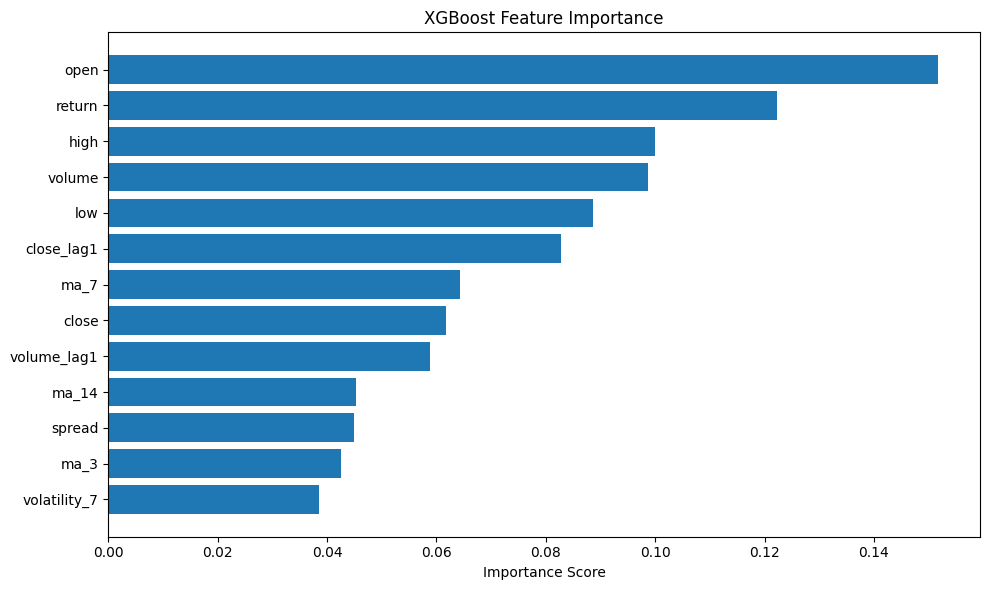

<Figure size 1000x600 with 0 Axes>

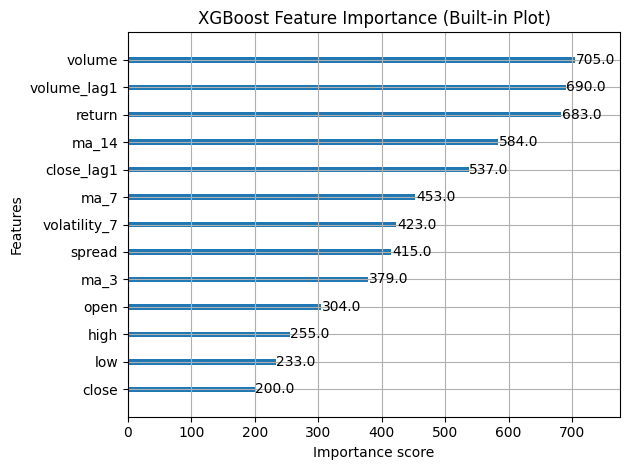

In [12]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
feature_importance = xgb_model.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.barh(np.array(features)[sorted_idx], feature_importance[sorted_idx])
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Plot feature importance using XGBoost's plot_importance function
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=len(features))
plt.title('XGBoost Feature Importance (Built-in Plot)')
plt.tight_layout()
plt.show()

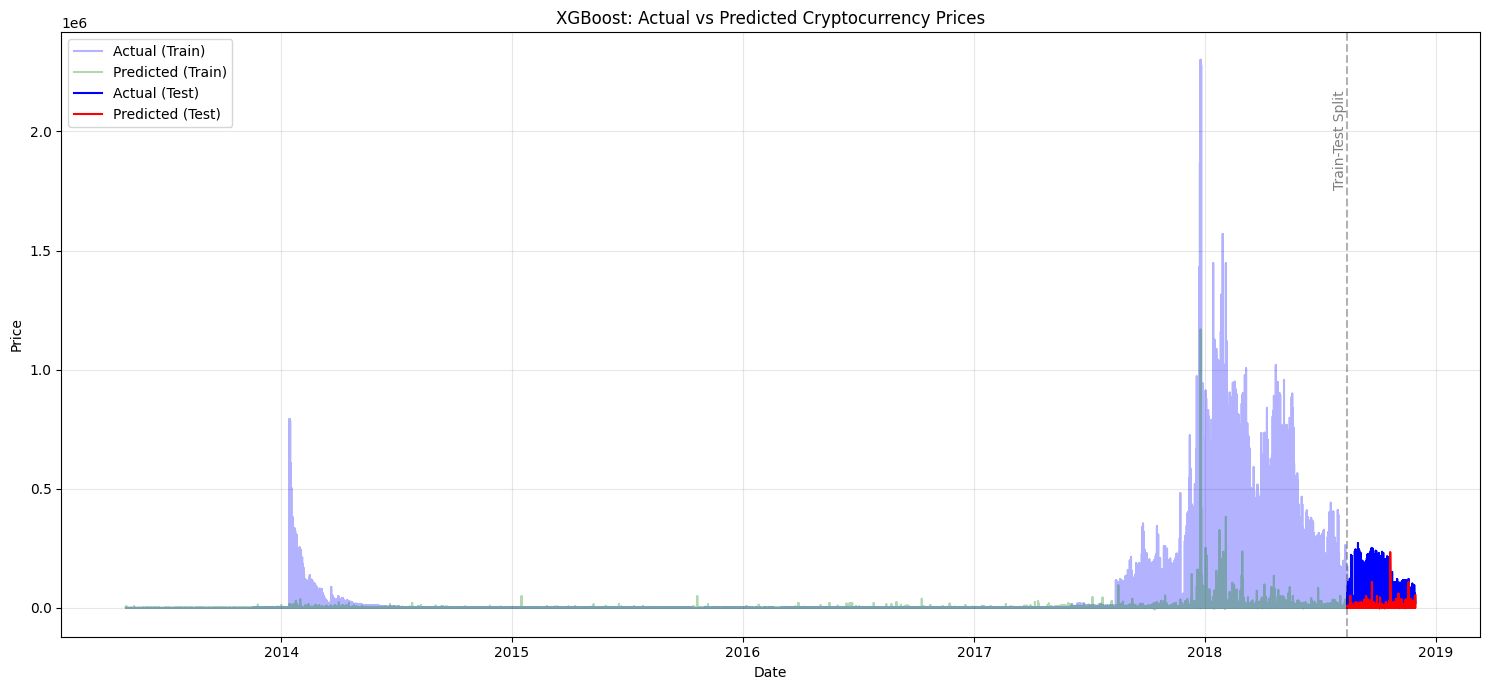

In [13]:
# Visualize actual vs predicted prices
plt.figure(figsize=(15, 7))

# Plot training data
plt.plot(dates_train, y_train, 'b-', label='Actual (Train)', alpha=0.3)
plt.plot(dates_train, train_preds, 'g-', label='Predicted (Train)', alpha=0.3)

# Plot test data
plt.plot(dates_test, y_test, 'b-', label='Actual (Test)')
plt.plot(dates_test, test_preds, 'r-', label='Predicted (Test)')

# Add vertical line to separate train and test sets
plt.axvline(x=dates_train.iloc[-1], color='k', linestyle='--', alpha=0.3)
plt.text(dates_train.iloc[-1], plt.ylim()[1]*0.9, 'Train-Test Split', 
         ha='right', va='top', rotation=90, alpha=0.5)

plt.title('XGBoost: Actual vs Predicted Cryptocurrency Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save Model and Metrics

Save the trained XGBoost model and its performance metrics for later use in model comparison.

In [ ]:
# Save the model and metadata
model_name = 'xgboost'
model_filename = f'./models/{model_name}_model.pkl'

# Save the model
with open(model_filename, 'wb') as f:
    pickle.dump(xgb_model, f)

# Save model metadata
model_metadata = {
    'name': 'XGBoost',
    'features': features,
    'metrics': {
        'train': train_metrics,
        'test': test_metrics
    },
    'params': params,
    'feature_importance': {feature: importance for feature, importance in zip(features, feature_importance)},
    'date_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'best_iteration': xgb_model.best_iteration if hasattr(xgb_model, 'best_iteration') else None
}

metadata_filename = f'./models/{model_name}_metadata.pkl'
with open(metadata_filename, 'wb') as f:
    pickle.dump(model_metadata, f)

# Save predictions
predictions = {
    'train': {
        'dates': dates_train,
        'actual': y_train,
        'predicted': train_preds
    },
    'test': {
        'dates': dates_test,
        'actual': y_test,
        'predicted': test_preds
    }
}

predictions_filename = f'./models/{model_name}_predictions.pkl'
with open(predictions_filename, 'wb') as f:
    pickle.dump(predictions, f)

print(f"Model saved to: {model_filename}")
print(f"Metadata saved to: {metadata_filename}")
print(f"Predictions saved to: {predictions_filename}")

Model saved to: ../models/xgboost_model.pkl
Metadata saved to: ../models/xgboost_metadata.pkl
Predictions saved to: ../models/xgboost_predictions.pkl
